In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

In [ ]:
df = pd.read_csv("/content/CC GENERAL.csv")

In [ ]:
print(df.head())
print(df.info())
print(df.describe())

  CUST_ID      BALANCE  ...  PRC_FULL_PAYMENT  TENURE
0  C10001    40.900749  ...          0.000000      12
1  C10002  3202.467416  ...          0.222222      12
2  C10003  2495.148862  ...          0.000000      12
3  C10004  1666.670542  ...          0.000000      12
4  C10005   817.714335  ...          0.000000      12

[5 rows x 18 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      895

In [ ]:
#Data Preprocessing
#customer id is not useful
#df.drop(columns=['CUST_ID'],inplace=True)

print("Null Values: \n",df.isnull().sum())
#drop null values
df.dropna(inplace=True)
scaler=StandardScaler()
X_scaled=scaler.fit_transform(df)

Null Values: 
 BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64


In [ ]:
print(X_scaled)

[[-0.74462486 -0.37004679 -0.42918384 ... -0.30550763 -0.53772694
   0.35518066]
 [ 0.76415211  0.06767893 -0.47320819 ...  0.08768873  0.21238001
   0.35518066]
 [ 0.42660239  0.50540465 -0.11641251 ... -0.09990611 -0.53772694
   0.35518066]
 ...
 [-0.75297728 -0.29709491 -0.40657175 ... -0.32957217  0.30614422
  -4.22180042]
 [-0.75772142 -0.29709491 -0.47320819 ... -0.34081076  0.30614422
  -4.22180042]
 [-0.58627829 -1.09958965  0.03129519 ... -0.32709767 -0.53772694
  -4.22180042]]


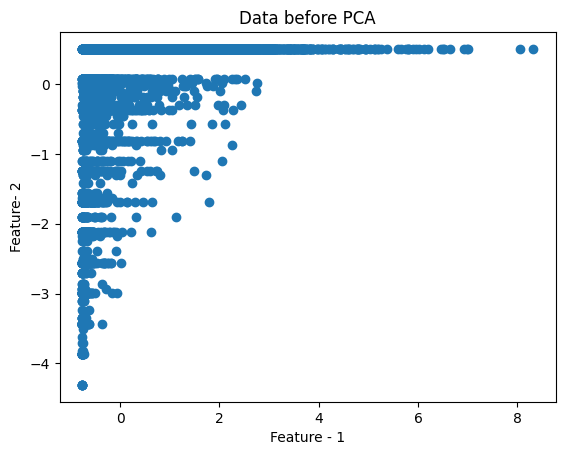

In [ ]:
plt.scatter(X_scaled[:,0],X_scaled[:,1])
plt.xlabel("Feature - 1")
plt.ylabel("Feature- 2")
plt.title("Data before PCA")
plt.show()

In [ ]:
#Developing K means model
wcss=[]
sil_scores=[]
K=range(2,11)
for k in K:
    kmeans=KMeans(n_clusters=k,random_state=42)
    labels=kmeans.fit_predict(X_scaled)
    wcss.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled,labels))

print(wcss)
print("Silhouette method:\n")
print(sil_scores)

[124507.21181603741, 108086.49495605758, 95661.10686235351, 88614.60726596712, 84003.80569529401, 77313.10328751558, 73475.61326772097, 70309.9131267193, 66026.35337638513]
Silhouette method:

[np.float64(0.2802136700845037), np.float64(0.24709726016009056), np.float64(0.2004866872384794), np.float64(0.19034732611741967), np.float64(0.19298863107757958), np.float64(0.2057751923371526), np.float64(0.1877927146965203), np.float64(0.19695464945721827), np.float64(0.22094944666155059)]


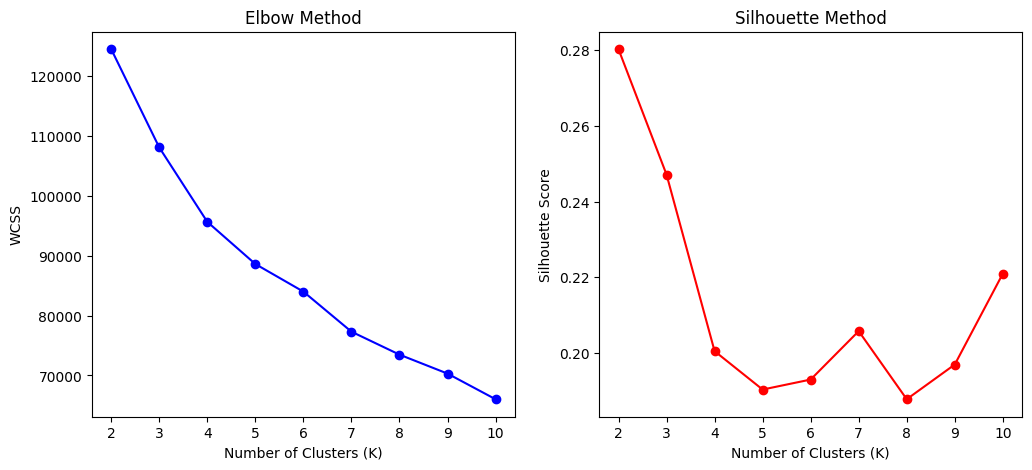

In [ ]:
#Plotting K vs WCSS and K vs Silhouette
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(K, wcss, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method')

plt.subplot(1, 2, 2)
plt.plot(K, sil_scores, 'ro-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method')

plt.show()

In [ ]:
best_k_silhouette=K[np.argmax(sil_scores)]
print("Best K (Silhoutte): ",best_k_silhouette)


Best K (Silhoutte):  2


In [ ]:
!pip install kneed

In [ ]:
from kneed import KneeLocator
knee=KneeLocator(K,wcss,curve='convex',direction='decreasing')

best_k_elbow=knee.elbow
print("Best K (Elbow): ",best_k_elbow)

Best K (Elbow):  4


In [ ]:
#Fit K means with best K
best_k=4
kmeans=KMeans(n_clusters=best_k,random_state=42)
clusters=kmeans.fit_predict(X_scaled)
df['Clusters']=clusters

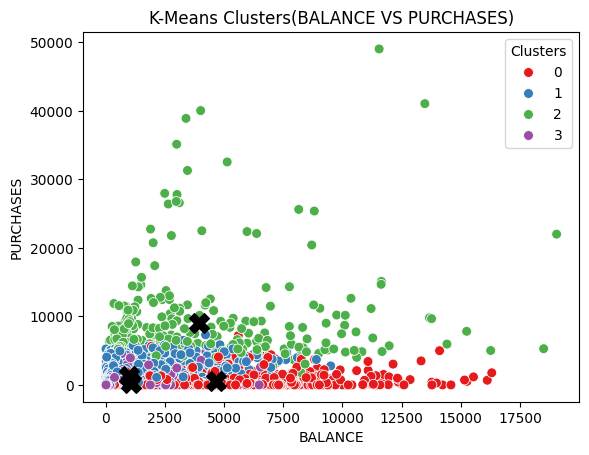

In [ ]:
sns.scatterplot(
    x='BALANCE',
    y='PURCHASES',
    hue='Clusters',
    data=df,
    palette='Set1',
    s=50
)
centroids=scaler.inverse_transform(kmeans.cluster_centers_)

plt.scatter(
    centroids[:,df.columns.get_loc('BALANCE')],
    centroids[:,df.columns.get_loc('PURCHASES')],
    marker='X',
    c='black',
    s=200,
    label='Centroids'
)
plt.title('K-Means Clusters(BALANCE VS PURCHASES)')
plt.xlabel('BALANCE')
plt.ylabel('PURCHASES')
plt.legend
plt.show()

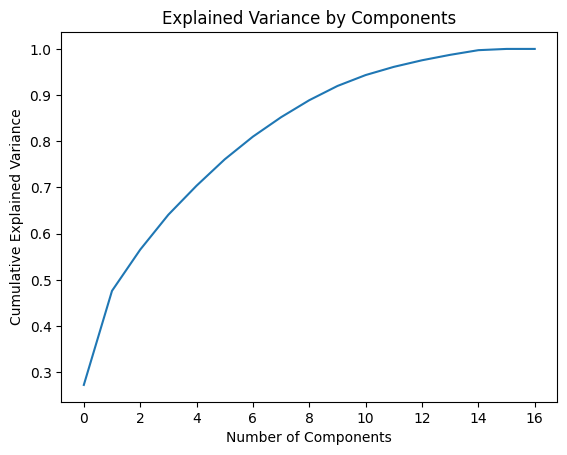

In [ ]:
pca=PCA()
X_pca=pca.fit_transform(X_scaled)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by Components')
plt.show()

In [ ]:
cumulative_variance=np.cumsum(pca.explained_variance_ratio_)
n_components=np.argmax(cumulative_variance>=0.95)+1
print("Optimal number of PCA components: ",n_components)

Optimal number of PCA components:  12


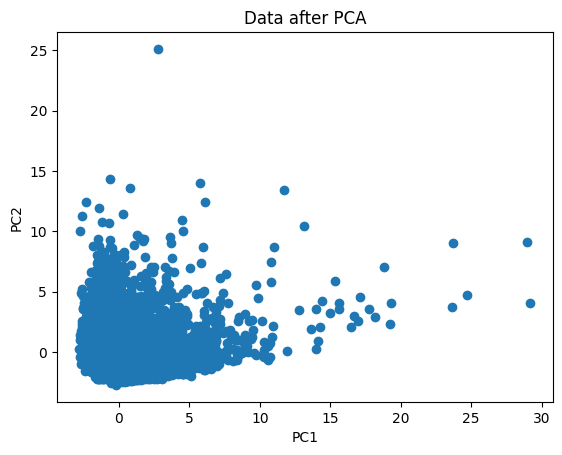

In [ ]:
pca=PCA(n_components=n_components)
X_pca=pca.fit_transform(X_scaled)
plt.scatter(X_pca[:,0],X_pca[:,1])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Data after PCA')
plt.show()

In [ ]:
#Developing K means model
wcss=[]
sil_scores=[]
K=range(2,11)
for k in K:
    kmeans=KMeans(n_clusters=k,random_state=42)
    labels=kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_pca,labels))

print(wcss)
print("Silhouette method:\n")
print(sil_scores)

[117586.6608889641, 103084.80541282726, 95945.6031369506, 83111.48813313918, 76274.66693777888, 71178.61577267724, 67830.26063617606, 64865.12984591736, 60484.390878521735]
Silhouette method:

[np.float64(0.21561769724309524), np.float64(0.2125523323815747), np.float64(0.18140355167632574), np.float64(0.20702829272837342), np.float64(0.21196591546856305), np.float64(0.224152421476558), np.float64(0.21656051383339867), np.float64(0.21202604508747666), np.float64(0.21570244270011704)]


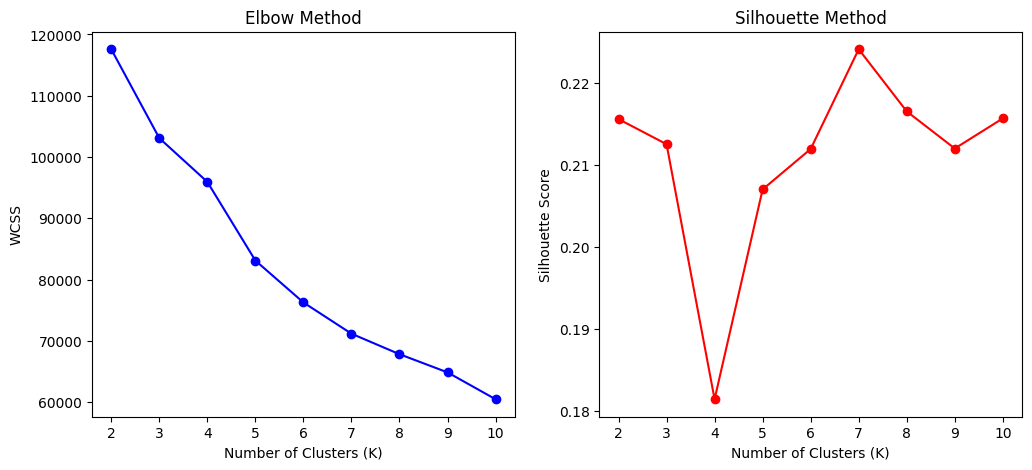

In [ ]:
#Plotting K vs WCSS and K vs Silhouette
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(K, wcss, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method')

plt.subplot(1, 2, 2)
plt.plot(K, sil_scores, 'ro-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method')

plt.show()

In [ ]:
best_k_silhouette=K[np.argmax(sil_scores)]
print("Best K (Silhoutte): ",best_k_silhouette)
from kneed import KneeLocator
knee=KneeLocator(K,wcss,curve='convex',direction='decreasing')

best_k_elbow=knee.elbow
print("Best K (Elbow): ",best_k_elbow)

Best K (Silhoutte):  7
Best K (Elbow):  5


In [ ]:
#Fit K means with best K
best_k=5
kmeans=KMeans(n_clusters=best_k,random_state=42)
clusters=kmeans.fit_predict(X_pca)
df['Clusters']=clusters

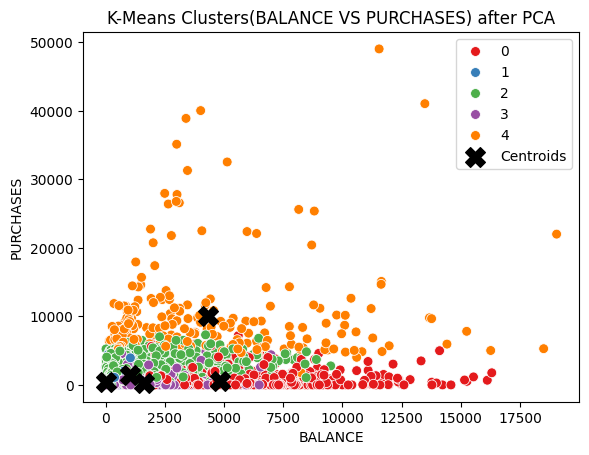

In [ ]:
sns.scatterplot(
    x='BALANCE',
    y='PURCHASES',
    hue='Clusters',
    data=df,
    palette='Set1',
    s=50
)

# Inverse transform centroids from PCA space back to original feature space, then unscale
centroids_pca_inverse = pca.inverse_transform(kmeans.cluster_centers_)
centroids_original_scale = scaler.inverse_transform(centroids_pca_inverse)

plt.scatter(
    centroids_original_scale[:,df.columns.get_loc('BALANCE')],
    centroids_original_scale[:,df.columns.get_loc('PURCHASES')],
    marker='X',
    c='black',
    s=200,
    label='Centroids'
)
plt.title('K-Means Clusters(BALANCE VS PURCHASES) after PCA')
plt.xlabel('BALANCE')
plt.ylabel('PURCHASES')
plt.legend()
plt.show()